In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:22px;}

</style>
"""))

# OpenAI API를 활용한 이미지 생성 및 편집 튜토리얼 

이 Jupyter Notebook에서는 OpenAI의 gpt-image-1-mini 모델 API를 활용하여 텍스트로부터 이미지 생성 및 기존 이미지 편집(Inpainting/Outpainting) 기능을 구현하는 방법을 소개합니다. 

### 주요 학습 내용:
1. gpt-image-1-mini 모델 개요 및 환경 설정
2. OpenAI API 클라이언트 생성
3. 기본 이미지 생성
4. 이미지 편집

## 1. gpt-image-1-mini 모델 개요

gpt-image-* 는 OpenAI가 개발한 최첨단 이미지 생성 AI 모델로, 텍스트로 설명한 내용을 바탕으로 새로운 이미지를 만들어냅니다. 예를 들어 *"우주비행사가 말을 타고 있는 사진"*이라는 프롬프트를 주면, 우주비행사가 말 위에 올라탄 독창적이고 현실감 있는 이미지를 생성할 수 있습니다. 자연어 설명만으로 사실적인 이미지와 예술 작품을 생성할 수 있으며, 여러 개념과 속성, 스타일을 조합하여 창의적인 결과물을 만들어냅니다. 

2023년에 공개된 DALL-E 2와 3 모델은 2026년 5월에 폐기함. 

## 2. OpenAI API 클라이언트 생성


In [2]:
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
client = OpenAI()


위 코드에서는 .env에서 불러온 API 키로 client 객체를 생성했습니다. 이제 이 client를 통해 DALL-E를 비롯한 OpenAI API 요청을 보낼 수 있습니다. (참고로, api_key를 생략하면 OPENAI_API_KEY 환경 변수를 자동으로 참조합니다.)

## 3. 기본 이미지 생성
텍스트 프롬프트를 사용한 이미지 생성은 gpt-image-1-mini의 가장 기본적인 기능입니다. 앞서 생성한 OpenAI client를 사용하여 원하는 내용을 설명하는 프롬프트를 전달하면, 해당 설명에 부합하는 이미지를 얻을 수 있습니다.

### 이미지 생성 요청하기
OpenAI Python SDK에서는 이미지 생성을 위해 client.images.generate() 메서드를 제공합니다. 가장 간단한 형태로 이 메서드에 프롬프트 문자열만 전달하면 한 장의 이미지를 생성합니다. 예를 들어 다음 코드는 "숲이 보이는 밝은 자연 이미지를 그려줘"이라는 간단한 프롬프트로 이미지를 생성하는 요청을 만듭니다:


In [3]:
prompt_text = '숲이 보이는 밝은 자연 이미지를 그려줘'
response = client.images.generate(
            model='gpt-image-1-mini', # 모델명
            prompt=prompt_text,       # 생성될 이미지 설명
            n=1,                      # 생성될 이미지 갯수   
            size="1024x1024"          # 이미지 해상도
)

In [5]:
import base64
b64_data = response.data[0].b64_json

image_bytes = base64.b64decode(b64_data)

with open('data/ch4_forest.png','wb')as f:
    f.write(image_bytes)
print('이미지 저장완료')

이미지 저장완료


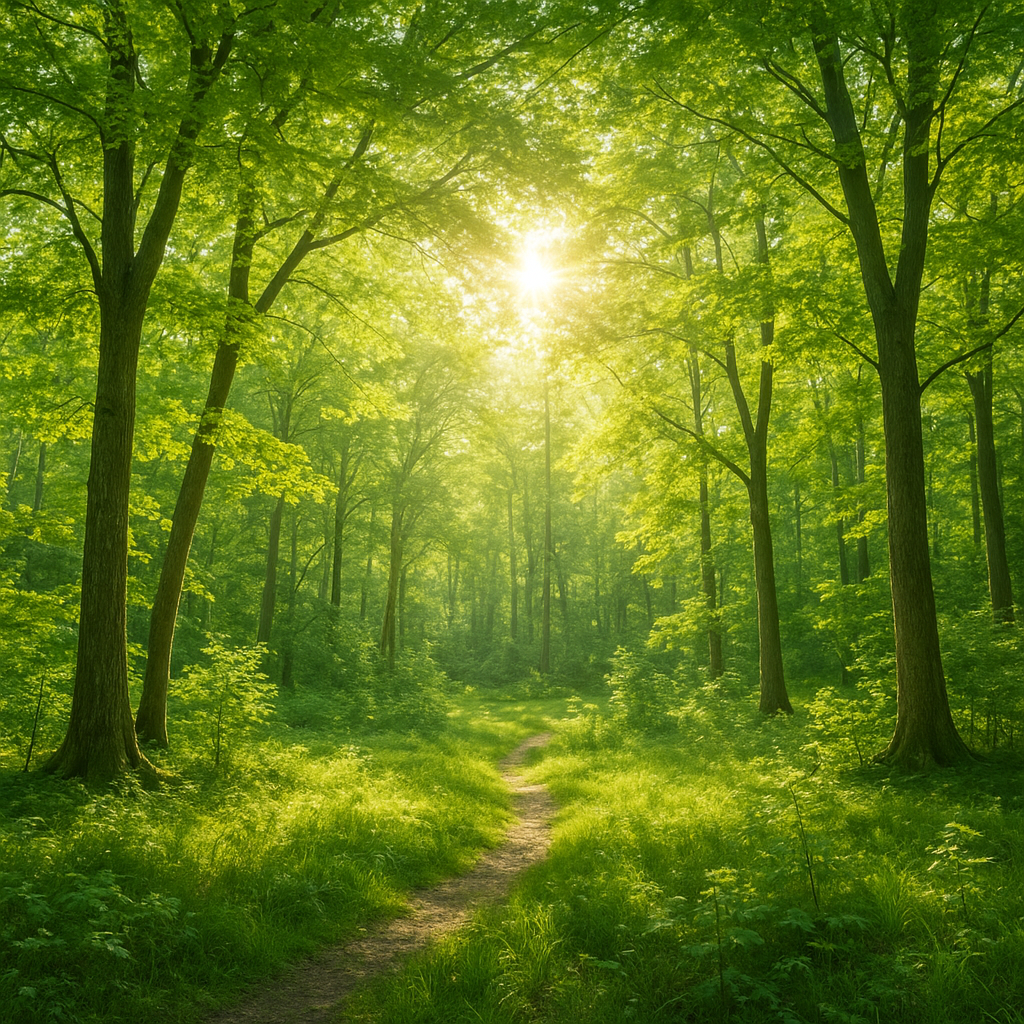

In [6]:
from IPython.display import display, Image
display(Image(image_bytes, width=200))

위 코드는 동일한 prompt에 quality="low" 옵션을 추가하여 이미지를 생성한 예시입니다. gpt-image-1-mini는 quality를 "low", "medium", "high", "auto"(기본값) 중에서 선택할 수 있으며, quality를 낮출수록 토큰 사용량과 비용이 줄어듭니다. 참고로 gpt-image-1-mini는 256x256, 512x512처럼 더 작은 정사각형 해상도는 지원하지 않으며, "1024x1024", "1536x1024", "1024x1536", "auto" 중에서만 크기를 선택할 수 있습니다(과거 DALL-E 2가 지원하던 256x256, 512x512 같은 작은 해상도는, DALL-E 2가 2026년 5월 API에서 제거되면서 함께 사라졌습니다).

참고: gpt-image-1-mini를 비롯한 GPT 이미지 계열 모델(gpt-image-1, gpt-image-1.5 등)은 URL이 아니라 항상 b64_json(base64로 인코딩된 이미지 데이터) 형태로만 결과를 반환합니다. 따라서 response.data[0].b64_json 값을 base64.b64decode()로 디코딩한 뒤 파일로 저장하거나 화면에 표시해야 합니다. (URL 방식은 과거 DALL-E 2, DALL-E 3에서 기본으로 제공되던 방식이었으나, 두 모델 모두 현재는 API에서 제거되어 더 이상 사용할 수 없습니다.)


In [ ]:
prompt_text = '숲이 보이는 밝은 자연 이미지를 그려줘'
response = client.images.generate(
            model='gpt-image-1-mini', # 모델명
            prompt=prompt_text,       # 생성될 이미지 설명
            n=1,                      # 생성될 이미지 갯수   
            size="1024x1024",         # 이미지 해상도
            quality='low'             # low/medium/high/auto 중 선택 낮을수록 토큰비용 절감. 기본값은 auto
)

In [ ]:
import base64
b64_data = response.data[0].b64_json

image_bytes = base64.b64decode(b64_data)

with open('data/ch4_forest.png','wb')as f:
    f.write(image_bytes)
print('이미지 저장완료')

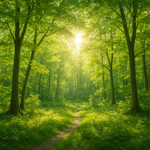

In [9]:
from PIL import Image
from io import BytesIO
# image = Image.open('data/ch4_forest.png')
image = Image.open(BytesIO(image_bytes))
image.resize((150,150))

### quality 옵션으로 고품질 이미지 생성하기
앞서 언급했듯, OpenAI는 한때 DALL-E 2(기본값)와 DALL-E 3 두 가지 모델을 이미지 생성 API로 제공했지만, 두 모델 모두 2026년 5월 API에서 제거되었습니다. 현재는 gpt-image-1-mini, gpt-image-1, gpt-image-1.5 등 GPT 이미지 계열 모델만 사용할 수 있으며, 이 중 토큰당 비용이 가장 저렴한 모델이 gpt-image-1-mini입니다. DALL-E 3가 제공하던 "고품질" 옵션은 gpt-image-1-mini의 quality 파라미터로 대체할 수 있습니다. 예를 들어 더 높은 품질의 이미지를 얻으려면 위 요청을 다음과 같이 변경합니다::


In [14]:
# gpt-image-1-mini 모델을 이용하여 1024x1024 이미지의 윗부분 편집(인패이팅)
original_image = open('data/ch4_original.png','rb')
mask_image     = open('data/ch4_mask.png','rb')

response = client.images.edit(
            model = 'gpt-image-1-mini',
            image = original_image,
            mask  = mask_image,
            prompt = '하늘에 구름 제거해줘',
            n = 1,
            size='1024x1024'
)